
# Hydroelectric Scheduling in Three Cascaded Dams

This notebook formulates and solves two nonlinear programming (NLP) models in **Pyomo** using **IPOPT**:

1. **Original cascade NLP:** three hydroelectric dams connected in series.
2. **Cascade NLP with pumped storage:** Dam 3 may continuously pump water back to Dam 2.

The source of nonlinearity is the hydropower equation

$$ P_{i,t}=\frac{\eta_i\rho g}{10^6}Q_{i,t}H_{i,t},$$

where hydraulic head depends on storage:

$$ H_{i,t}=H_i^0+\alpha_i S_{i,t}. $$

Thus,

$$ P_{i,t} = \frac{\eta_i\rho g}{10^6} Q_{i,t}(H_i^0+\alpha_iS_{i,t}), $$

which contains the bilinear product $Q_{i,t}S_{i,t}$.


In [1]:
import pyomo.environ as pyo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Section 1 — Original Three-Dam Cascade NLP

We consider three reservoirs connected in cascade:

$$ \text{Dam 1} \rightarrow \text{Dam 2} \rightarrow \text{Dam 3}. $$

Water released through the turbine of an upstream dam immediately becomes inflow to the next downstream reservoir. Travel time, spillage, evaporation, and environmental releases are neglected in this introductory model.

## Decision variables

For dam $i\in\{1,2,3\}$ and hour $t\in\{1,\ldots,24\}$:

* $S_{i,t}$ = reservoir storage at the end of hour $t. [\mathrm{m^3}] $
* $Q_{i,t}$ = turbine release during hour $t. [\mathrm{m^3/s}]$
* $P_{i,t}$ = electrical power generation $ [\mathrm{MW}]$

The hydraulic head $H_{i,t}$ is a derived quantity from the volume of water $S_{i,t}$ stored in dam $i$,

$$ H_{i,t}=H_i^0+S_{i,t}/A_i. $$

where $A_i$ is the reservoir surface area, assuming that the dam is a perfect rectangular box.

## Fixed parameters

* $\rho$ = water density $[\mathrm{kg/m^3}]$
* $g$ = gravitational acceleration $[\mathrm{m/s^2}]$
* $\eta_i$ = turbine-generator efficiency
* $H_i^0$ = base hydraulic head $[\mathrm{m}]$
* $A_i$ = constant reservoir surface area $[\mathrm{m^2}]$
* $S_i^{\min},S_i^{\max}$ = minimum and maximum reservoir storage $[\mathrm{m^3}]$
* $S_i^{init}$ = initial reservoir storage $[\mathrm{m^3}]$
* $Q_i^{\max}$ = maximum turbine release $[\mathrm{m^3/s}]$
* $I_{i,t}$ = natural inflow $[\mathrm{m^3/s}]$
* $\pi_t$ = electricity price $[\$/\mathrm{MWh}]$
* $\Delta t$ = 3600 $\mathrm{s}$ or 1 hr.

for one-hour scheduling intervals.

## Objective Function

The operator maximizes electricity-market revenue:

$$ \max \sum_t \pi_t \left(\sum_i P_{i,t} \right) \Delta t. $$

## Constraints

### Reservoir balance for Dam 1, 2, 3
The water stored in dam $i$ at time $t$, $S_{i,t}$, increases with natural inflow $I_{i,t}$ and water flow from the previous dam $Q_{i-1,t}$ but decreases with water out $Q_{i,t}$. 

$$ S_{1,t} = S_{1,t-1} + \Delta t (I_{1,t}-Q_{1,t}). $$
$$ S_{2,t} = S_{2,t-1} + \Delta t (I_{2,t}+Q_{1,t}-Q_{2,t}).$$
$$ S_{3,t} = S_{3,t-1} + \Delta t (I_{3,t}+Q_{2,t}-Q_{3,t}).$$

For $t=1$, $S_{i,0}=S_i^{init}$.

### Storage bounds
The water outflow cannot cause the stored water to go lower than $S_i^{min}$. Since there is no spillway, any water inflow that causes the stored water to exceed $S_i^{max}$ must be released and hence produces energy.

$$ S_i^{\min} \leq S_{i,t} \leq S_i^{\max}.$$

### Turbine-flow bounds
Turbine $i$ cannot take more than $Q_i^{max}$ amount of released water.

$$0 \leq Q_{i,t} \leq Q_i^{\max}.$$

### Nonlinear hydropower equation
Since hydroelectric power comes from potential energy, then $P_{i,t} = \eta_i \rho g Q_{i,t} H_{i,t}$. The hydraulic head can be written as $H_{i,t} = H_i^0+S_{i,t}/A_i$ for each dam $i$ at time $t$. Thus, we have:

$$ P_{i,t} = \frac{\eta_i\rho g}{10^6} Q_{i,t} \left(H_i^0+\frac{S_{i,t}}{A_i} \right).$$

The division by $10^6$ converts watts to megawatts. This is nonlinear because $Q_{i,t}$ and $S_{i,t}$ are multiplied together.
 
### Terminal-storage requirement

$$ S_{i,24} \geq S_i^{init}.$$

This prevents the optimizer from obtaining artificial profit by simply emptying the reservoirs at the end of the horizon.

In [2]:
T = list(range(1, 25))
DAMS = [1, 2, 3]

rho = 1000.0       # kg/m3
g = 9.81           # m/s2
dt = 3600.0        # s per hour

eta = {1: 0.90, 2: 0.91, 3: 0.92}
H0 = {1: 35.0, 2: 30.0, 3: 25.0}
A = {1: 5.0e6, 2: 5.6e6, 3: 6.7e6}
Smin = {1: 2.0e6, 2: 1.5e6, 3: 1.0e6}
Smax = {1: 8.0e6, 2: 6.0e6, 3: 5.0e6}
Sinit = {1: 5.0e6, 2: 4.0e6, 3: 3.0e6}
Qmax = {1: 70.0, 2: 80.0, 3: 90.0}

# Natural inflows [m3/s]
inflow = {}

for t in T:
    inflow[1, t] = 35.0 + 5.0*np.sin(2*np.pi*(t-1)/24)
    inflow[2, t] = 12.0
    inflow[3, t] = 8.0

# Electricity price [$ / MWh]
price_profile = [
    40, 38, 35, 34, 35, 40,
    50, 65, 80, 90, 85, 75,
    65, 60, 58, 60, 70, 90,
    110, 120, 115, 95, 70, 55
]

price = {t: price_profile[t-1] for t in T}

In [3]:
m1 = pyo.ConcreteModel()

m1.I = pyo.Set(initialize=DAMS)
m1.T = pyo.Set(initialize=T, ordered=True)

# ----------------------------
# Decision variables
# ----------------------------

def storage_bounds(m, i, t):
    return Smin[i], Smax[i]

m1.S = pyo.Var(m1.I, m1.T, bounds=storage_bounds,
    initialize=lambda m, i, t: Sinit[i])

def flow_bounds(m, i, t):
    return 0.0, Qmax[i]

m1.Q = pyo.Var(m1.I, m1.T, bounds=flow_bounds,
    initialize=30.0)

m1.P = pyo.Var(m1.I, m1.T, bounds=(0.0, None),
    initialize=20.0)

# ----------------------------
# Nonlinear power equation
# ----------------------------

def power_rule(m, i, t):
    head = H0[i] + m.S[i, t]/A[i]
    return m.P[i, t] == eta[i] * rho * g * m.Q[i, t] * head / 1e6

m1.PowerEquation = pyo.Constraint(m1.I, m1.T,
    rule=power_rule)

# ----------------------------
# Reservoir balances
# ----------------------------

def storage_balance_1(m, t):
    Sprev = Sinit[1] if t == 1 else m.S[1, t-1]
    return m.S[1, t] == Sprev + dt*(inflow[1, t] - m.Q[1, t])

m1.StorageBalance1 = pyo.Constraint(m1.T, rule=storage_balance_1)

def storage_balance_2(m, t):
    Sprev = Sinit[2] if t == 1 else m.S[2, t-1]
    return m.S[2, t] == Sprev + dt*(inflow[2, t] + m.Q[1, t] - m.Q[2, t])

m1.StorageBalance2 = pyo.Constraint(m1.T, rule=storage_balance_2)

def storage_balance_3(m, t):
    Sprev = Sinit[3] if t == 1 else m.S[3, t-1]
    return m.S[3, t] == Sprev + dt*(inflow[3, t] + m.Q[2, t] - m.Q[3, t])

m1.StorageBalance3 = pyo.Constraint(m1.T, rule=storage_balance_3)

# ----------------------------
# Terminal storage
# ----------------------------

def terminal_storage_rule(m, i):
    return m.S[i, 24] >= Sinit[i]

m1.TerminalStorage = pyo.Constraint(m1.I, rule=terminal_storage_rule)

# ----------------------------
# Objective
# ----------------------------

def objective_rule_1(m):
    return sum(price[t] * sum(m.P[i, t] for i in m.I) for t in m.T)

m1.obj = pyo.Objective(rule=objective_rule_1, sense=pyo.maximize)

# ----------------------------
# Solve
# ----------------------------

solver = pyo.SolverFactory("ipopt")
results1 = solver.solve(m1, tee=True)

print("Termination condition:",
      results1.solver.termination_condition)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:      477
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:       72

Total number of variables............................:      216
                     variables with only lower bounds:       72
                variables with lower and upper bounds:      144
                     variables with only upper bounds:        0
Total number of equality constraints.................:      144
Total number

## Record results and plot

In [4]:
records1 = []

for t in T:
    row = {
        "Hour": t,
        "Price": price[t]
    }

    for i in DAMS:
        S = pyo.value(m1.S[i, t])
        Q = pyo.value(m1.Q[i, t])
        P = pyo.value(m1.P[i, t])
        H = H0[i] + S/A[i]

        row[f"S{i}"] = S
        row[f"Q{i}"] = Q
        row[f"H{i}"] = H
        row[f"P{i}"] = P

    records1.append(row)

df1 = pd.DataFrame(records1)
df1["Total Power"] = df1["P1"] + df1["P2"] + df1["P3"]

total_revenue_1 = sum(
    price[t] * sum(pyo.value(m1.P[i, t]) for i in DAMS)
    for t in T
)

print(f"Total revenue = ${total_revenue_1:,.2f}")
df1.round(2)

Total revenue = $75,429.94


,Hour,Price,S1,Q1,H1,P1,S2,Q2,H2,P2,S3,Q3,H3,P3,Total Power
0,1,40,5126000.00,-0.0,36.03,-0.00,4043200.00,-0.00,30.72,-0.00,3028800.00,-0.0,25.45,-0.00,-0.00
1,2,38,5256658.74,-0.0,36.05,-0.00,4086400.00,-0.00,30.73,-0.00,3057600.00,-0.0,25.46,-0.00,-0.00
2,3,35,5391658.74,-0.0,36.08,-0.00,4129600.00,-0.00,30.74,-0.00,3086400.00,-0.0,25.46,-0.00,-0.00
3,4,34,5530386.67,-0.0,36.11,-0.00,4172800.00,-0.00,30.75,-0.00,3115200.00,-0.0,25.46,-0.00,-0.00
4,5,35,5671975.12,-0.0,36.13,-0.00,4216000.00,-0.00,30.75,-0.00,3144000.00,-0.0,25.47,-0.00,-0.00
5,6,40,5815361.79,-0.0,36.16,-0.00,4259200.00,-0.00,30.76,-0.00,3172800.00,-0.0,25.47,-0.00,-0.00
6,7,50,5959361.79,-0.0,36.19,-0.00,4302400.00,-0.00,30.77,-0.00,3201600.00,-0.0,25.48,-0.00,-0.00
7,8,65,5850748.48,70.0,36.17,22.35,4309599.97,80.00,30.77,21.97,3194400.00,90.0,25.48,20.69,65.02
8,9,80,5740336.93,70.0,36.15,22.34,4316799.97,80.00,30.77,21.98,3187200.00,90.0,25.48,20.69,65.01
9,10,90,5627064.85,70.0,36.13,22.33,4323999.97,80.00,30.77,21.98,3180000.00,90.0,25.47,20.69,65.00


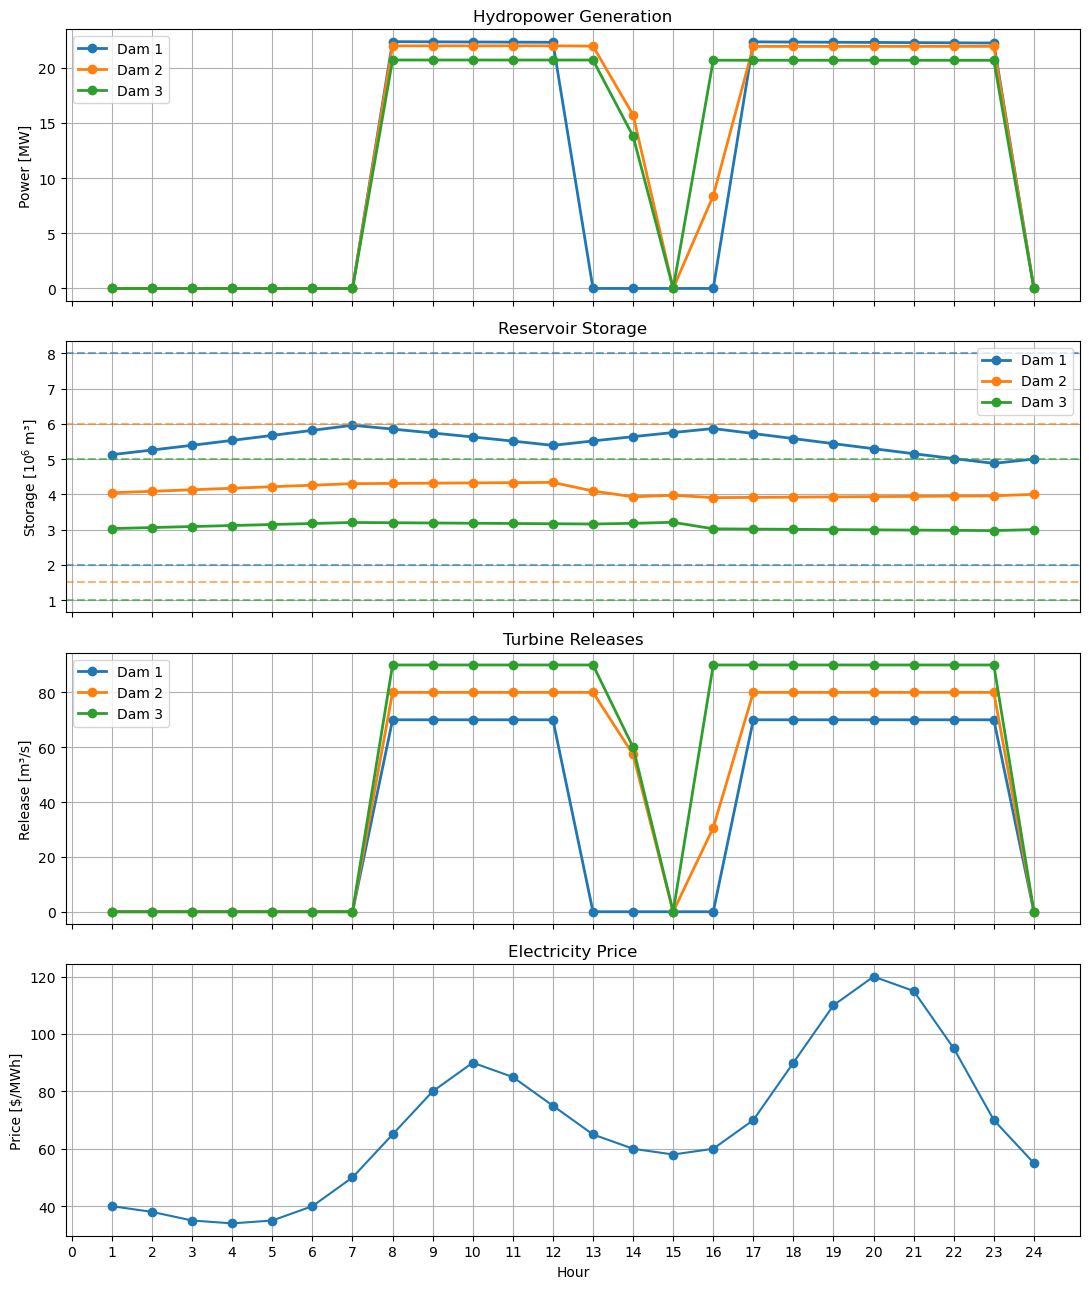

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(11, 13), sharex=True)

# 1. Power generation
ax[0].plot(df1["Hour"], df1["P1"], marker="o", linewidth=2, label="Dam 1")
ax[0].plot(df1["Hour"], df1["P2"], marker="o", linewidth=2, label="Dam 2")
ax[0].plot(df1["Hour"], df1["P3"], marker="o", linewidth=2, label="Dam 3")
ax[0].set_ylabel("Power [MW]")
ax[0].set_title("Hydropower Generation")
ax[0].legend()
ax[0].grid(True)

# 2. Reservoir storage
for i in DAMS:
    line, = ax[1].plot(df1["Hour"], df1[f"S{i}"]/1e6,
        marker="o", linewidth=2, label=f"Dam {i}")

    color = line.get_color()

    ax[1].axhline(Smin[i]/1e6, color=color,
        linestyle="--", alpha=0.6)
    ax[1].axhline(Smax[i]/1e6, color=color,
        linestyle="--", alpha=0.6)

ax[1].set_ylabel("Storage [$10^6$ m³]")
ax[1].set_title("Reservoir Storage")
ax[1].legend()
ax[1].grid(True)

# 3. Turbine releases
ax[2].plot(df1["Hour"], df1["Q1"], marker="o", linewidth=2, label="Dam 1")
ax[2].plot(df1["Hour"], df1["Q2"], marker="o", linewidth=2, label="Dam 2")
ax[2].plot(df1["Hour"], df1["Q3"], marker="o", linewidth=2, label="Dam 3")
ax[2].set_ylabel("Release [m³/s]")
ax[2].set_title("Turbine Releases")
ax[2].legend()
ax[2].grid(True)

# 4. Price
ax[3].plot(df1["Hour"], df1["Price"], marker="o")
ax[3].set_ylabel("Price [$/MWh]")
ax[3].set_xlabel("Hour")
ax[3].set_title("Electricity Price")
ax[3].grid(True)

ax[3].set_xticks(range(25))
plt.tight_layout()
plt.show()


# Section 2 — NLP with Continuous Pumping from Dam 3 to Dam 2

We now allow a pump to move water **upstream from Dam 3 to Dam 2**. The pumping rate remains a *continuous* variable, so the optimization problem is still an NLP rather than a MINLP.

The original variables, parameters, and hydropower equations remain unchanged.

## New decision variable

* $Q_t^{pump}$ = water pumped from Dam 3 to Dam 2 $[\mathrm{m^3/s}]$

with $ 0 \leq Q_t^{pump} \leq Q^{pump,\max}.$

## New fixed values

We introduce:

* $Q^{pump,\max}$ = maximum pumping flow rate
* $\eta^{pump}$ = pump efficiency
* $c^{pump}$ = degradation cost for operating pump

For this example,

$$ Q^{pump,\max}=30\ \mathrm{m^3/s}$$
$$\eta^{pump}=0.85.$$

The pumping head is approximated as the elevation difference between the water surfaces of Dams 2 and 3:

$$ H_t^{pump} = H_{2,t}-H_{3,t}.$$

The electrical power consumed by the pump is therefore

$$ P_t^{pump} = \frac{\rho g}{10^6\eta^{pump}} Q_t^{pump} H_t^{pump}.$$

Because $H_t^{pump}$ depends on reservoir storage, this expression is also nonlinear.

## Modified objective

The pump consumes electricity for every $P_t^{pump}$ and also incurs degradation / maintenance cost via $c^{pump}$ proportional to the $Q_t^{pump}$. Hence, net revenue becomes:

$$ \max \sum_t \left[ \pi_t \left(\sum_i P_{i,t} - P_t^{pump}\right) \Delta t - c^{pump} Q_t^{pump} \Delta t \right]. $$

This allows the optimizer to pump water during inexpensive hours and generate additional electricity later when the price is higher.

## Modified constraints

Pumped water now enters Dam 2 in addition to the inflow from Dam 1 ($Q_{1,t}$) and natural inflow ($I_{2,t}$):

$$ S_{2,t} = S_{2,t-1} + \Delta t \left( I_{2,t} + Q_{1,t} - Q_{2,t} + Q_t^{pump}\right).$$

The same pumped water leaves Dam 3:

$$ S_{3,t} = S_{3,t-1} + \Delta t \left( I_{3,t} + Q_{2,t} - Q_{3,t} - Q_t^{pump} \right).$$

### New pumping-power equation

$$ P_t^{pump} = \frac{\rho g}{10^6\eta^{pump}} Q_t^{pump} \left[\left(H_2^0+\frac{S_{2,t}}{A_2}\right) - \left(H_3^0+\frac{S_{3,t}}{A_3}\right) \right].$$

No binary variable is introduced. Therefore, this remains a **continuous NLP**.


In [6]:
Qpump_max = 30.0    # maximum pumping flow [m3/s]
eta_pump = 0.85     # pumping efficiency
c_pump = 10         # degradation / maintenance cost [$/m^3]

In [7]:
# ============================================================
# SECTION 2 MODEL
# ============================================================

m2 = pyo.ConcreteModel()

m2.I = pyo.Set(initialize=DAMS)
m2.T = pyo.Set(initialize=T, ordered=True)

# Original variables
m2.S = pyo.Var(m2.I, m2.T, bounds=storage_bounds,
    initialize=lambda m, i, t: Sinit[i])

m2.Q = pyo.Var(m2.I, m2.T, bounds=flow_bounds,
    initialize=30.0)

m2.P = pyo.Var(m2.I, m2.T, bounds=(0.0, None),
    initialize=20.0)

# New continuous pumping variables
m2.Qpump = pyo.Var(m2.T, bounds=(0.0, Qpump_max),
    initialize=0.0)

m2.Ppump = pyo.Var(m2.T, bounds=(0.0, None),
    initialize=0.0)

# ----------------------------
# Original hydropower equation
# ----------------------------

def power_rule_2(m, i, t):
    head = H0[i] + m.S[i, t]/A[i]
    return m.P[i, t] == eta[i] * rho * g * m.Q[i, t] * head / 1e6

m2.PowerEquation = pyo.Constraint(m2.I, m2.T,
    rule=power_rule_2)

# ----------------------------
# New pumping-power equation
# ----------------------------

def pumping_power_rule(m, t):
    H2 = H0[2] + m.S[2, t]/A[2]
    H3 = H0[3] + m.S[3, t]/A[3]

    return m.Ppump[t] == rho * g * m.Qpump[t] * (H2 - H3) / (eta_pump * 1e6)

m2.PumpingPower = pyo.Constraint(m2.T, rule=pumping_power_rule)

# ----------------------------
# Dam 1 balance: unchanged
# ----------------------------

def storage_balance_1_pump(m, t):
    Sprev = Sinit[1] if t == 1 else m.S[1, t-1]
    return m.S[1, t] == Sprev + dt*(inflow[1, t] - m.Q[1, t])

m2.StorageBalance1 = pyo.Constraint(m2.T, rule=storage_balance_1_pump)

# ----------------------------
# Dam 2 balance: MODIFIED
# ----------------------------

def storage_balance_2_pump(m, t):
    Sprev = Sinit[2] if t == 1 else m.S[2, t-1]
    return m.S[2, t] == Sprev + dt*(inflow[2, t] + m.Q[1, t] - m.Q[2, t] + m.Qpump[t])
    
m2.StorageBalance2 = pyo.Constraint(m2.T, rule=storage_balance_2_pump)

# ----------------------------
# Dam 3 balance: MODIFIED
# ----------------------------

def storage_balance_3_pump(m, t):
    Sprev = Sinit[3] if t == 1 else m.S[3, t-1]
    return m.S[3, t] == Sprev + dt*(inflow[3, t] + m.Q[2, t] - m.Q[3, t] - m.Qpump[t])

m2.StorageBalance3 = pyo.Constraint(m2.T, rule=storage_balance_3_pump)

# ----------------------------
# Terminal storage: unchanged
# ----------------------------

m2.TerminalStorage = pyo.Constraint(m2.I, rule=terminal_storage_rule)

# ----------------------------
# Objective: MODIFIED
# ----------------------------

def objective_rule_2(m):
    net_revenue = sum(price[t] * (sum(m.P[i, t] for i in m.I) - m.Ppump[t]) for t in m.T)
    pumping_penalty = sum(c_pump * m.Qpump[t] for t in m.T)
    return net_revenue - pumping_penalty

m2.obj = pyo.Objective(rule=objective_rule_2, sense=pyo.maximize)

# ----------------------------
# Solve
# ----------------------------

solver = pyo.SolverFactory("ipopt")
results2 = solver.solve(m2, tee=True)

print("Termination condition:",
      results2.solver.termination_condition)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:      621
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:      120

Total number of variables............................:      264
                     variables with only lower bounds:       96
                variables with lower and upper bounds:      168
                     variables with only upper bounds:        0
Total number of equality constraints.................:      168
Total number

## Record results and plot

In [8]:
records2 = []

for t in T:
    row = {
        "Hour": t,
        "Price": price[t],
        "Qpump": pyo.value(m2.Qpump[t]),
        "Ppump": pyo.value(m2.Ppump[t])
    }

    for i in DAMS:
        S = pyo.value(m2.S[i, t])
        Q = pyo.value(m2.Q[i, t])
        P = pyo.value(m2.P[i, t])
        H = H0[i] + S/A[i]

        row[f"S{i}"] = S
        row[f"Q{i}"] = Q
        row[f"H{i}"] = H
        row[f"P{i}"] = P

    records2.append(row)

df2 = pd.DataFrame(records2)

df2["Gross Power"] = df2["P1"] + df2["P2"] + df2["P3"]
df2["Net Power"] = df2["Gross Power"] - df2["Ppump"]

total_revenue_2 = sum(price[t] * (sum(pyo.value(m2.P[i, t]) for i in DAMS) - pyo.value(m2.Ppump[t])) for t in T)

print(f"Total net revenue = ${total_revenue_2:,.2f}")
df2.round(2)

Total net revenue = $79,327.99


,Hour,Price,Qpump,Ppump,S1,Q1,H1,P1,S2,Q2,H2,P2,S3,Q3,H3,P3,Gross Power,Net Power
0,1,40,30.0,1.84,5126000.00,-0.0,36.03,-0.00,4151200.00,-0.0,30.74,-0.00,2920800.00,-0.0,25.44,-0.00,-0.00,-1.84
1,2,38,30.0,1.85,5256658.74,-0.0,36.05,-0.00,4302400.00,-0.0,30.77,-0.00,2841600.00,-0.0,25.42,-0.00,-0.00,-1.85
2,3,35,30.0,1.86,5391658.74,-0.0,36.08,-0.00,4453600.00,-0.0,30.80,-0.00,2762400.00,-0.0,25.41,-0.00,-0.00,-1.86
3,4,34,30.0,1.88,5530386.67,-0.0,36.11,-0.00,4604800.00,-0.0,30.82,-0.00,2683200.00,-0.0,25.40,-0.00,-0.00,-1.88
4,5,35,30.0,1.89,5671975.12,-0.0,36.13,-0.00,4756000.01,-0.0,30.85,-0.00,2603999.99,-0.0,25.39,-0.00,-0.00,-1.89
5,6,40,30.0,1.90,5815361.79,-0.0,36.16,-0.00,4907200.01,-0.0,30.88,-0.00,2524799.99,-0.0,25.38,-0.00,-0.00,-1.90
6,7,50,30.0,1.88,5959361.79,-0.0,36.19,-0.00,4770400.00,80.0,30.85,22.03,2733600.00,-0.0,25.41,-0.00,22.03,20.15
7,8,65,-0.0,-0.00,5850748.48,70.0,36.17,22.35,4777599.97,80.0,30.85,22.03,2726399.99,90.0,25.41,20.64,65.03,65.03
8,9,80,-0.0,-0.00,5740336.93,70.0,36.15,22.34,4784799.97,80.0,30.85,22.04,2719199.99,90.0,25.41,20.64,65.01,65.01
9,10,90,-0.0,-0.00,5627064.85,70.0,36.13,22.33,4791999.97,80.0,30.86,22.04,2711999.99,90.0,25.40,20.64,65.00,65.00


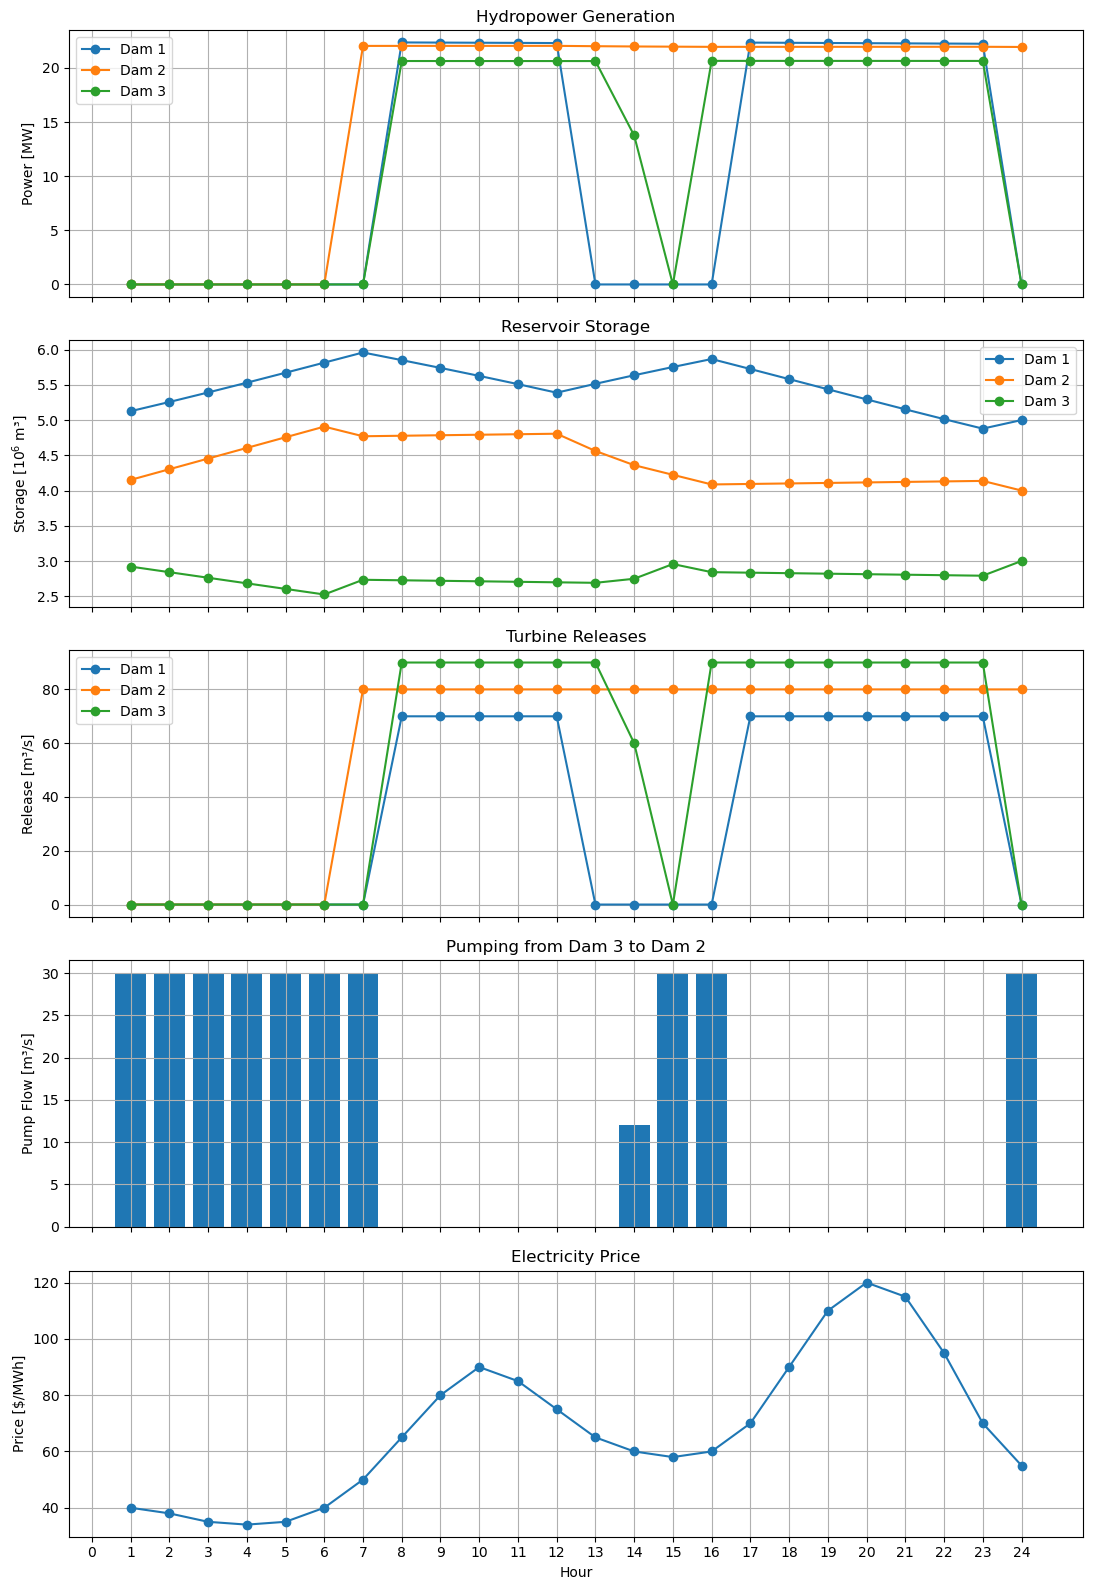

In [9]:
fig, ax = plt.subplots(5, 1, figsize=(11, 16), sharex=True)

# 1. Hydropower generation
ax[0].plot(df2["Hour"], df2["P1"], marker="o", label="Dam 1")
ax[0].plot(df2["Hour"], df2["P2"], marker="o", label="Dam 2")
ax[0].plot(df2["Hour"], df2["P3"], marker="o", label="Dam 3")
ax[0].set_ylabel("Power [MW]")
ax[0].set_title("Hydropower Generation")
ax[0].legend()
ax[0].grid(True)

# 2. Reservoir storage
ax[1].plot(df2["Hour"], df2["S1"]/1e6, marker="o", label="Dam 1")
ax[1].plot(df2["Hour"], df2["S2"]/1e6, marker="o", label="Dam 2")
ax[1].plot(df2["Hour"], df2["S3"]/1e6, marker="o", label="Dam 3")
ax[1].set_ylabel("Storage [$10^6$ m³]")
ax[1].set_title("Reservoir Storage")
ax[1].legend()
ax[1].grid(True)

# 3. Turbine releases
ax[2].plot(df2["Hour"], df2["Q1"], marker="o", label="Dam 1")
ax[2].plot(df2["Hour"], df2["Q2"], marker="o", label="Dam 2")
ax[2].plot(df2["Hour"], df2["Q3"], marker="o", label="Dam 3")
ax[2].set_ylabel("Release [m³/s]")
ax[2].set_title("Turbine Releases")
ax[2].legend()
ax[2].grid(True)

# 4. Pump operation
ax[3].bar(df2["Hour"], df2["Qpump"], label="Pumped flow")
ax[3].set_ylabel("Pump Flow [m³/s]")
ax[3].set_title("Pumping from Dam 3 to Dam 2")
ax[3].grid(True)

# 5. Electricity price
ax[4].plot(df2["Hour"], df2["Price"], marker="o")
ax[4].set_ylabel("Price [$/MWh]")
ax[4].set_xlabel("Hour")
ax[4].set_title("Electricity Price")
ax[4].grid(True)

ax[4].set_xticks(range(25))
plt.tight_layout()
plt.show()


## Comparison of the Two NLPs

The pumped-storage model may earn greater revenue by using low-price electricity to move water from Dam 3 back to Dam 2. The same water can subsequently pass through the turbines of Dam 2 and Dam 3 again during higher-price periods.

Because $Q_t^{pump}$ is continuous, this remains an NLP. A binary pump/generate operating-mode variable would instead turn the formulation into a mixed-integer nonlinear program (MINLP).


In [10]:
comparison = pd.DataFrame({
    "Case": [
        "Original cascade NLP",
        "Cascade NLP with continuous pumping"
    ],
    "Revenue [$]": [
        total_revenue_1,
        total_revenue_2
    ]
})

comparison["Revenue improvement [$]"] = (
    comparison["Revenue [$]"] - total_revenue_1
)

comparison.round(2)

,Case,Revenue [$],Revenue improvement [$]
0,Original cascade NLP,75429.94,0.00
1,Cascade NLP with continuous pumping,79327.99,3898.05
